:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_02_ND_basis_function.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(composing_basis_function)=
# Composing Basis Functions

## Background

In many cases, it's necessary to model the response of a neuron to multiple different inputs
(such as velocity, spatial position, LFP phase, etc.). Such response functions can often be expressed as a linear
combination of some multidimensional basis elements.

In this document, we introduce two strategies for defining a high-dimensional basis function by combining
two lower-dimensional bases. We refer to these strategies as "addition" and "multiplication" of bases,
and the resulting basis objects will be referred to as additive or multiplicative basis respectively: additive bases have their component bases operate *independently*, whereas multiplicative bases take the *outer product*. And these composite basis objects can be constructed using other composite bases, so that you can combine them as much as you'd like!

More precisely, let's say we have two inputs $\mathbf{x} \in \mathbb{R}^N,\; \mathbf{y}\in \mathbb{R}^M$.
Let's say we've defined two basis functions for these inputs:

- $ [ a_0 (\mathbf{x}), ..., a_{k-1} (\mathbf{x}) ] $ for $\mathbf{x}$
- $ [b_0 (\mathbf{y}), ..., b_{h-1} (\mathbf{y}) ] $ for $\mathbf{y}$.

These basis functions can be combined in the following ways:

1. **Addition:** If we assume that there is no interaction between the stimuli, the response function can be adequately described by the sum of the individual components. The function is defined as:

   $$
   f(\mathbf{x}, \mathbf{y}) \approx \sum_{i=0}^{k-1} \alpha_{i} \, a_i (\mathbf{x})  + \sum_{j=0}^{h-1} \beta_j b_j(\mathbf{y}).
   $$

   The resulting additive basis simply consists of the concatenation of the two basis sets:

   $$
   [A_0 (\mathbf{x}, \mathbf{y}), ..., A_{k+h-1} (\mathbf{x}, \mathbf{y})],
   $$

   where

   $$
   A_j(\mathbf{x}, \mathbf{y}) = \begin{cases} a_j(\mathbf{x}) &\text{if }\; j \leq k-1 \\
   b_{j-k+1}(\mathbf{y}) &\text{otherwise.} \end{cases}
   $$

   Note that we have a total of $k+h$ basis elements, and that each element is constant in one of the axis.

2. **Multiplication:** If we expect the response function to capture arbitrary interactions between the inputs, we can approximate it as the external product of the two bases:

   $$
   f(\mathbf{x}, \mathbf{y}) \approx \sum_{i=0}^{k-1}\sum_{j=0}^{h-1} \alpha_{ij} \, a_i (\mathbf{x}) b_j(\mathbf{y}).
   $$

   In this case, the resulting basis consists of the $h \cdot k$ products of the individual bases:

   $$
   [A_0(\mathbf{x}, \mathbf{y}),..., A_{k \cdot h-1}(\mathbf{x}, \mathbf{y})],
   $$

   where,

   $$
   A_{i \cdot h + j}(\mathbf{x}, \mathbf{y}) = a_i(\mathbf{x})b_{j}(\mathbf{y}), \; \text{for} \; i=0,\dots, k-1 \; \text{ and } \; j=0,\dots,h-1.
   $$

In the subsequent sections, we will:

1. Demonstrate the definition, evaluation, and visualization of 2D additive and multiplicative bases.
2. Illustrate how to iteratively apply addition and multiplication operations to extend to dimensions beyond two.

(composite_basis_2d)=
## 2D Basis Functions

Consider an instance where we want to capture a neuron's response to an animal's position within a given arena.
In this scenario, the stimuli are the 2D coordinates (x, y) that represent the animal's position at each time point.



### Additive Basis Object
One way to model the response to our 2D stimuli is to hypothesize that it decomposes into two factors:
one due to the x-coordinate and another due to the y-coordinate. We can express this relationship as:

$$
f(x,y) \approx \sum_i \alpha_i \cdot a_i(x) + \sum_j \beta_j \cdot b_j(y).
$$

Here, we simply add two basis objects, `a_basis` and `b_basis`, together to define the additive basis.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo

# Define 1D basis objects
a_basis = nmo.basis.MSplineEval(n_basis_funcs=15, order=3, label="a")
b_basis = nmo.basis.RaisedCosineLogEval(n_basis_funcs=14, label="b")

# Define the 2D additive basis object
additive_basis = a_basis + b_basis
additive_basis

,label,'(a + b)'
,a__bounds,None
,a__fill_value,nan
,a__label,'a'
,a__n_basis_funcs,15
,a__order,3
,a,"'a': MSplineE...s=15, order=3)"
,b__bounds,None
,b__enforce_decay_to_zero,True
,b__fill_value,nan
,b__label,'b'


Evaluating the additive basis will require two inputs, one for each coordinate.
The total number of elements of the additive basis will be the sum of the elements of the 1D basis.

In [3]:
# Define a trajectory with 1000 time-points representing the recorded trajectory of the animal
T = 1000

# Define two variables
x_coord = np.linspace(0, 1, 1000)
y_coord = np.linspace(0, 1, 1000)

# Evaluate the basis functions for the given trajectory.
eval_basis = additive_basis.compute_features(x_coord, y_coord)

print(f"Sum of two 1D splines with {eval_basis.shape[1]} "
      f"basis element and {eval_basis.shape[0]} samples:\n"
      f"\t- a_basis had {additive_basis['a'].n_basis_funcs} elements.\n"
      f"\t- b_basis had {additive_basis['b'].n_basis_funcs} elements.")

Sum of two 1D splines with 29 basis element and 1000 samples:
	- a_basis had 15 elements.
	- b_basis had 14 elements.


(plotting-2d-additive-basis-elements)=
#### Plotting 2D Additive Basis Elements
Let's select and plot a basis element from each of the basis we added.

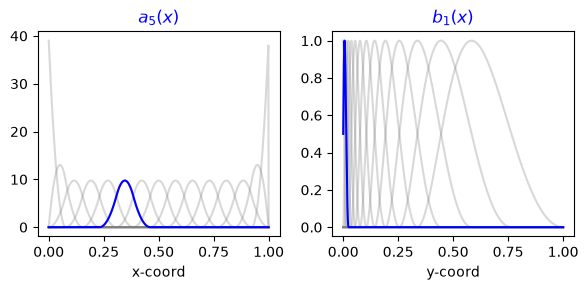

In [4]:
basis_a_element = 5
basis_b_element = 1
# Plot the 1D basis elements
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].set_title(f"$a_{{{basis_a_element}}}(x)$", color="b")
axs[0].plot(x_coord, a_basis.compute_features(x_coord), "grey", alpha=.3)
axs[0].plot(x_coord, a_basis.compute_features(x_coord)[:, basis_a_element], "b")
axs[0].set_xlabel("x-coord")

axs[1].set_title(f"$b_{{{basis_b_element}}}(x)$", color="b")
axs[1].plot(y_coord, b_basis.compute_features(x_coord), "grey", alpha=.3)
axs[1].plot(y_coord, b_basis.compute_features(x_coord)[:, basis_b_element], "b")
axs[1].set_xlabel("y-coord")
plt.tight_layout()

We can visualize how these elements are extended in 2D by evaluating the additive basis
on a grid of points that spans its domain and plotting the result.
We use the `evaluate_on_grid` method for this.

In [5]:
X, Y, Z = additive_basis.evaluate_on_grid(200, 200)

We can select the indices of the 2D additive basis that corresponds to the 1D original elements.

In [6]:
basis_elem_idx = [basis_a_element, a_basis.n_basis_funcs + basis_b_element]

Finally, we can plot the 2D counterparts.

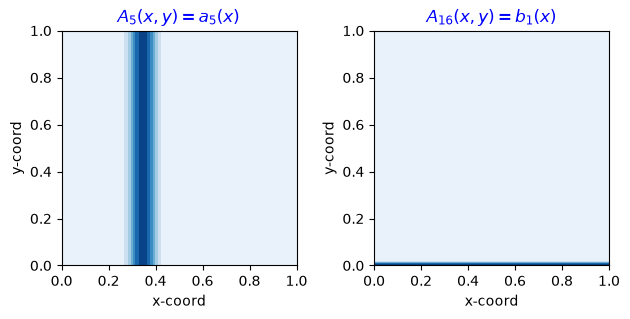

In [7]:
_, axs = plt.subplots(1, 2, subplot_kw={'aspect': 1})

# Plot the corresponding 2D elements.
# As expected, each element will be constant on one of the axis.
axs[0].set_title(f"$A_{{{basis_elem_idx[0]}}}(x,y) = "
                 f"a_{{{basis_a_element}}}(x)$", color="b")

axs[1].set_title(f"$A_{{{basis_elem_idx[1]}}}(x,y) = "
                 f"b_{{{basis_b_element}}}(x)$", color="b")

for cc in range(len(basis_elem_idx)):
    axs[cc].contourf(X, Y, Z[..., basis_elem_idx[cc]], cmap="Blues")
    axs[cc].set_xlabel("x-coord")
    axs[cc].set_ylabel("y-coord")
plt.tight_layout()
plt.show()

If we don't want to do the index algebra ourself, we can use the `split_by_feature` method to split `Z` for each additive element of the basis.

In [8]:
Z_split = additive_basis.split_by_feature(Z, axis=-1)
print(Z_split["a"].shape, Z_split["b"].shape)

(200, 200, 15) (200, 200, 14)


And then index directly the splitted array.

In [9]:
element_a, element_b = Z_split["a"][basis_a_element], Z_split["b"][basis_b_element]

### Multiplicative Basis Object

If the aim is to capture interactions between the coordinates, the response function can be modeled as the external
product of two 1D basis functions. The approximation of the response function in this scenario would be:

$$
f(x, y) \approx \sum_{ij} \alpha_{ij} \, a_i (x) b_j(y).
$$

In this model, we define the 2D basis function as the product of two 1D basis objects.
This allows the response to capture non-linear and interaction effects between the x and y coordinates.

In [10]:
# 2D basis function as the product of the two 1D basis objects
prod_basis = a_basis * b_basis

Again evaluating the basis will require 2 inputs.
The number of elements of the product basis will be the product of the elements of the two 1D bases.

In [11]:
# Evaluate the product basis at the x and y coordinates
eval_basis = prod_basis.compute_features(x_coord, y_coord)

# Output the number of elements and samples of the evaluated basis,
# as well as the number of elements in the original 1D basis objects
print(f"Product of two 1D splines with {eval_basis.shape[1]} "
      f"basis element and {eval_basis.shape[0]} samples:\n"
      f"\t- a_basis had {a_basis.n_basis_funcs} elements\n\t- b_basis had {b_basis.n_basis_funcs} elements.")

Product of two 1D splines with 210 basis element and 1000 samples:
	- a_basis had 15 elements
	- b_basis had 14 elements.


#### Plotting 2D Multiplicative Basis Elements
Plotting works in the same way as before. To demonstrate that, we select a few pairs of 1D basis elements,
and we visualize the corresponding product.

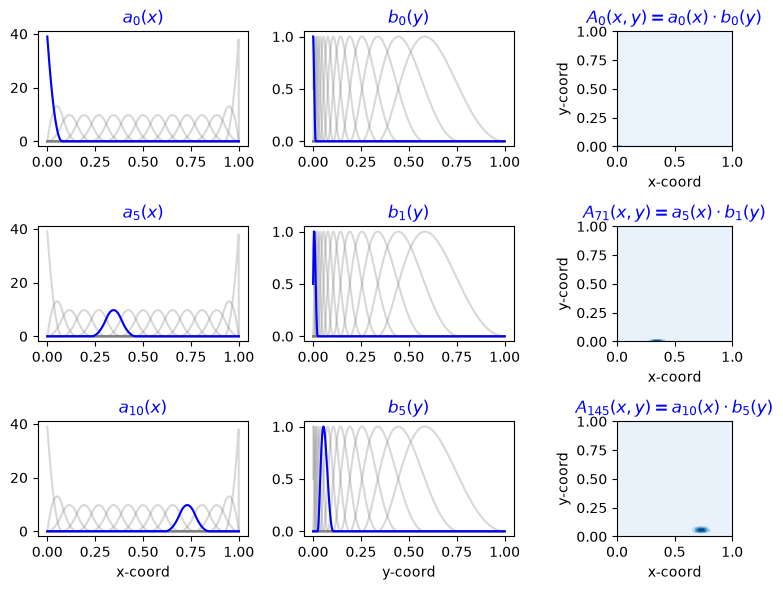

In [12]:
X, Y, Z = prod_basis.evaluate_on_grid(200, 200)

# basis element pairs
element_pairs = [[0, 0], [5, 1], [10, 5]]

# plot the 1D basis element and their product
fig, axs = plt.subplots(3,3,figsize=(8, 6))
cc = 0
for i, j in element_pairs:
    # plot the element form a_basis
    axs[cc, 0].plot(x_coord, a_basis.compute_features(x_coord), "grey", alpha=.3)
    axs[cc, 0].plot(x_coord, a_basis.compute_features(x_coord)[:, i], "b")
    axs[cc, 0].set_title(f"$a_{{{i}}}(x)$",color='b')

    # plot the element form b_basis
    axs[cc, 1].plot(y_coord, b_basis.compute_features(y_coord), "grey", alpha=.3)
    axs[cc, 1].plot(y_coord, b_basis.compute_features(y_coord)[:, j], "b")
    axs[cc, 1].set_title(f"$b_{{{j}}}(y)$",color='b')

    # select & plot the corresponding product basis element
    k = i * b_basis.n_basis_funcs + j
    axs[cc, 2].contourf(X, Y, Z[:, :, k], cmap='Blues')
    axs[cc, 2].set_title(fr"$A_{{{k}}}(x,y) = a_{{{i}}}(x) \cdot b_{{{j}}}(y)$", color='b')
    axs[cc, 2].set_xlabel('x-coord')
    axs[cc, 2].set_ylabel('y-coord')
    axs[cc, 2].set_aspect("equal")

    cc += 1
axs[2, 0].set_xlabel('x-coord')
axs[2, 1].set_xlabel('y-coord')

plt.tight_layout()

:::{note}
Basis objects of different types can be combined through multiplication or addition.
This feature is particularly useful when one of the axes represents a periodic variable and another is non-periodic.
A practical example would be characterizing the responses to position
in a linear maze and the LFP phase angle.
:::

N-Dimensional Basis
-------------------
Sometimes it may be useful to model even higher dimensional interactions, for example between the heding direction of
an animal and its spatial position. In order to model an N-dimensional response function, you can combine
N 1D basis objects using additions and multiplications.

:::{warning}
If you multiply basis together, the dimension of the evaluated basis function
will increase exponentially with the number of dimensions potentially causing memory errors.
For example, evaluating a product of $N$ 1D bases with $T$ samples and $K$ basis element,
will output a $K^N \times T$ matrix.
:::

In [13]:
T = 10
n_basis = 8

a_basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=n_basis)
b_basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=n_basis)
c_basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=n_basis)

prod_basis_3 = a_basis * b_basis * c_basis
samples = np.linspace(0, 1, T)
eval_basis = prod_basis_3.compute_features(samples, samples, samples)

print(f"Product of three 1D splines results in {prod_basis_3.n_basis_funcs} "
      f"basis elements.\nEvaluation output of shape {eval_basis.shape}")

Product of three 1D splines results in 512 basis elements.
Evaluation output of shape (10, 512)


The evaluation of the product of 3 basis is a 4 dimensional tensor; we can visualize slices of it.

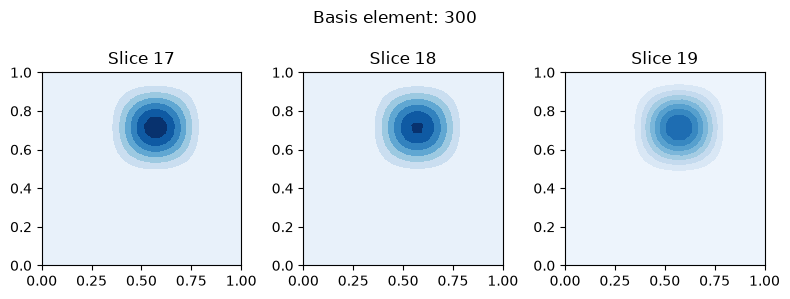

Sparsity check:  90.89% of the evaluated basis is null.


In [14]:
X, Y, W, Z = prod_basis_3.evaluate_on_grid(30, 30, 30)

# select any slice
slices = [17, 18, 19]
basis_elem_idx = 300
vmax = Z[:, :, slices, basis_elem_idx].max()
fig, axs = plt.subplots(1, 3, figsize=(8, 3))
cnt = 0
for slice_i in slices:
    X_slice = X[:, :, slice_i]
    Y_slice = Y[:, :, slice_i]

    Z_slice = Z[:, :, slice_i]
    axs[cnt].contourf(X_slice, Y_slice, Z_slice[:, :, basis_elem_idx],
                      cmap='Blues', vmin=0, vmax=vmax)
    axs[cnt].set_title(f"Slice {slice_i}")
    cnt += 1

plt.suptitle(f"Basis element: {basis_elem_idx}")
plt.tight_layout()
plt.show()

# Check sparsity
print(f"Sparsity check: {(Z == 0).sum() / Z.size * 100: .2f}% of the evaluated basis is null.")

:::{note}
The evaluated basis is going to be **sparse** if the basis elements support do not cover the
full domain of the basis.
:::



Here we demonstrate a shortcut syntax for multiplying bases of the same class.
This is achieved using the power operator with an integer exponent.

In [15]:
# First, let's define a basis `power_basis` that is equivalent to `prod_basis_3`,
# but we use the power syntax this time:
power_basis = a_basis**3

# Now, evaluate the `prod_basis_3` on a 30x30x30 grid and get the last item, let's call it `Z_pow`:
Z_pow_syntax = power_basis.evaluate_on_grid(30, 30, 30)[-1]
Z_prod_syntax = (a_basis * a_basis * a_basis).evaluate_on_grid(30, 30, 30)[-1]

# We can now assert that the original basis and the new `power_basis` match.
# If they do, the total number of mismatched entries should be zero.
print(f"Total mismatched entries: {(Z_pow_syntax != Z_prod_syntax).sum()}")

Total mismatched entries: 0
